# Name
Please write your name down here:

Peter Brederlow

**Unsupervised machine learning techniques**

Today we will continue working with the gene expression data of our mice, and try to find patterns in them with the help of unsupervised machine learning algorithms. Unsupervised methods are useful when we have so-called *unlabeled* data: samples with no group membership information, only their raw values.

Of course our expression data isn't unlabeled: we know for every sample 1) what diet it had, 2) what strain it was. But we won't give that information from the upcoming ML methods. We will instead ask these methods to score / separate / cluster the samples based on their raw values only, and then we will verify whether they did it in a way which is consistent with the labels that we had hidden from the algorithms.

The unsupervised techniques we will use today are principal component analysis (PCA), hierarchical clustering and K-means clustering, provided by the feature-rich and easy-to-use `scikit-learn` package. Their website is worth taking a look at for anyone interested in machine learning: it's not just a documentation, but also a great guide for a lot of techniques.

In [51]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

from scipy.stats import pearsonr

np.random.seed(42)

# Load the expression data

We will need the original raw expression data (in an unstacked `split_cd_hfd` format), and the differential expression analysis csv. Run the boxes below to make sure we all work on data in the same format.

In [52]:
def split_cd_hfd(input_df):
    input_df.index.name = 'gene'  # change that weird @format=column Excel index label to something meaningful
    input_cd = input_df.filter(regex=r'_CD|CD_') # loc[:, (input_df.columns.str.contains('CD_')) | (input_df.columns.str.contains('_CD'))]
    input_hfd = input_df.filter(regex=r'_HFD|HFD_') #loc[:, (input_df.columns.str.contains('HFD_')) | (input_df.columns.str.contains('_HFD'))]

    input_cd.columns = input_cd.columns.str.replace(r'_CD|CD_', '', regex=True)
    input_hfd.columns = input_hfd.columns.str.replace(r'_HFD|HFD_', '', regex=True)
    
    input_cd.insert(0, 'diet', 'CD')
    input_hfd.insert(0, 'diet', 'HFD')
    
    kept_columns = input_cd.columns.intersection(input_hfd.columns)
    
    df_both = pd.concat([input_cd, input_hfd], sort=False)[kept_columns]
    df_both.columns.name = 'strain'  # added only later
    
    return df_both.reset_index().set_index(['gene', 'diet']).sort_index()

xls = pd.read_excel('https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/main/data/expression.xlsx', header=2)
expr = xls.groupby('Gene.1').mean(numeric_only=True).filter(regex='Liver')  # or 'Gene' if you had used that for your DE calculations
expr.columns = expr.columns.str.replace('_Liver', '')
expr2 = split_cd_hfd(expr).unstack()

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


In [53]:
is_hfd = pd.Series((expr2.columns.get_level_values('diet') == 'HFD'), index=expr2.columns)  # diet labels for verification
is_hfd.name = 'is_hfd'
is_hfd2 = is_hfd.copy()

# Since `scikit-learn` likes to treat data as one sample per row, we should transpose our expression data matrix, such that rows stand for mice/diet combinations and columns stand for the gene expression values measured by the microarray. Let's call the transposed form of `expr2` as `data`.

data = expr2.T
data.columns = data.columns.astype(str)
data.head()

# And finally load your differential expression summary `diffexpr` from Day 5 for later use. (log2 fold changes, p-values etc.)

diffexpr = pd.read_csv('https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/main/data/diffexpr.csv')
diffexpr.set_index('gene', inplace=True)
diffexpr

,log2fold,p_mwu,p_wilcoxon,p_student,p_corr,interesting
gene,,,,,,
544988,-0.041726,2.461825e-03,6.844498e-03,2.471637e-02,0.007086,False
100043387,-0.094410,1.588075e-01,2.887933e-02,1.105006e-01,0.238169,False
0610007C21Rik,-0.011872,3.684131e-01,5.046829e-01,5.986195e-01,0.468540,False
0610007L01Rik,0.007372,9.561658e-01,5.387091e-01,6.891828e-01,0.971427,False
0610007P08Rik,-0.061718,4.618156e-02,2.996658e-02,6.733311e-02,0.085016,False
...,...,...,...,...,...,...
Zzz3,0.153692,9.250000e-07,1.010000e-07,2.320000e-07,0.000008,False
a,-0.059923,2.760128e-01,1.239942e-01,1.713445e-01,0.372528,False
l7Rn6,-0.122462,1.454909e-02,6.288770e-04,8.665480e-03,0.032398,False


# Principal component analysis
PCA takes a set of high-dimensional samples (vectors), and transforms them to lower dimensional vectors using a linear transformation. Based on the data, it finds an optimal list of unit length vectors (called principal directions) and projects (or in another interpretation: rotates) the data onto these principal directions with a simple dot product (aka a weighted sum). You can think about these principal directions as feature weight vectors, and the principal component scores as the weighted sums that they produce on your data.

The strength of PCA is in how it chooses these principal directions. The first principal direction is the unit length weight vector that maximizes the variance of the weighted sums when applied on your input vectors. The second principal direction is guaranteed to be orthogonal to the first one (i.e. uncorrelated with it) and also maximizes the variance of the output under this constraint. The third one is orthogonal to both the first and the second... and so on.

Usually the first few principal components _"explain most of the variance"_ in your data: the corresponding principal directions have large weights in the dimensions where your data shows a lot of variance, and low weights elsewhere. The orthogonality (uncorrelatedness) of the principal directions guarantees that they capture new sources of variance with each additional step.

Of course PCA is a deep topic and requires a good grasp on linear algebra to understand it in detail, but there are plenty of online resources and textbooks that can help you with that if you're interested. A rough understanding and some hands-on examples can still take us a long way.

##  Initialize a PCA object with 4 components and transform your data
Browse `scikit-learn`'s documentation to see how. Call the PCA object as `pca_model` and remember not to overwrite it later. Store the resulting principal component values in `pc_values`. You will see that it's a 78x4 numpy matrix, where 78 stands for the number of samples you had, and 4 is the number of principal components that you had calculated for them.

In [54]:
# YOUR CODE HERE
pca_model = PCA(n_components=4)
pca_result = pca_model.fit_transform(data) 
pca_result = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])], index=data.index)
pc_values = pca_model.explained_variance_ratio_
print("Explained variance by each principal component:", pc_values)


Explained variance by each principal component: [0.14774729 0.09669774 0.06629019 0.0421944 ]


## Plot the principal components against each other

Plotting the first principal component against the second is simple enough with matplotlib's `scatter`, but we can do better and create a scatter plot for each pair using seaborn's `pairplot`. This requires your data to be a `DataFrame`, but you know how to turn a numpy matrix into a DF: just pass it to `pd.DataFrame(...)` and name it as `pc_df`. Include the proper row indices while you're at it.

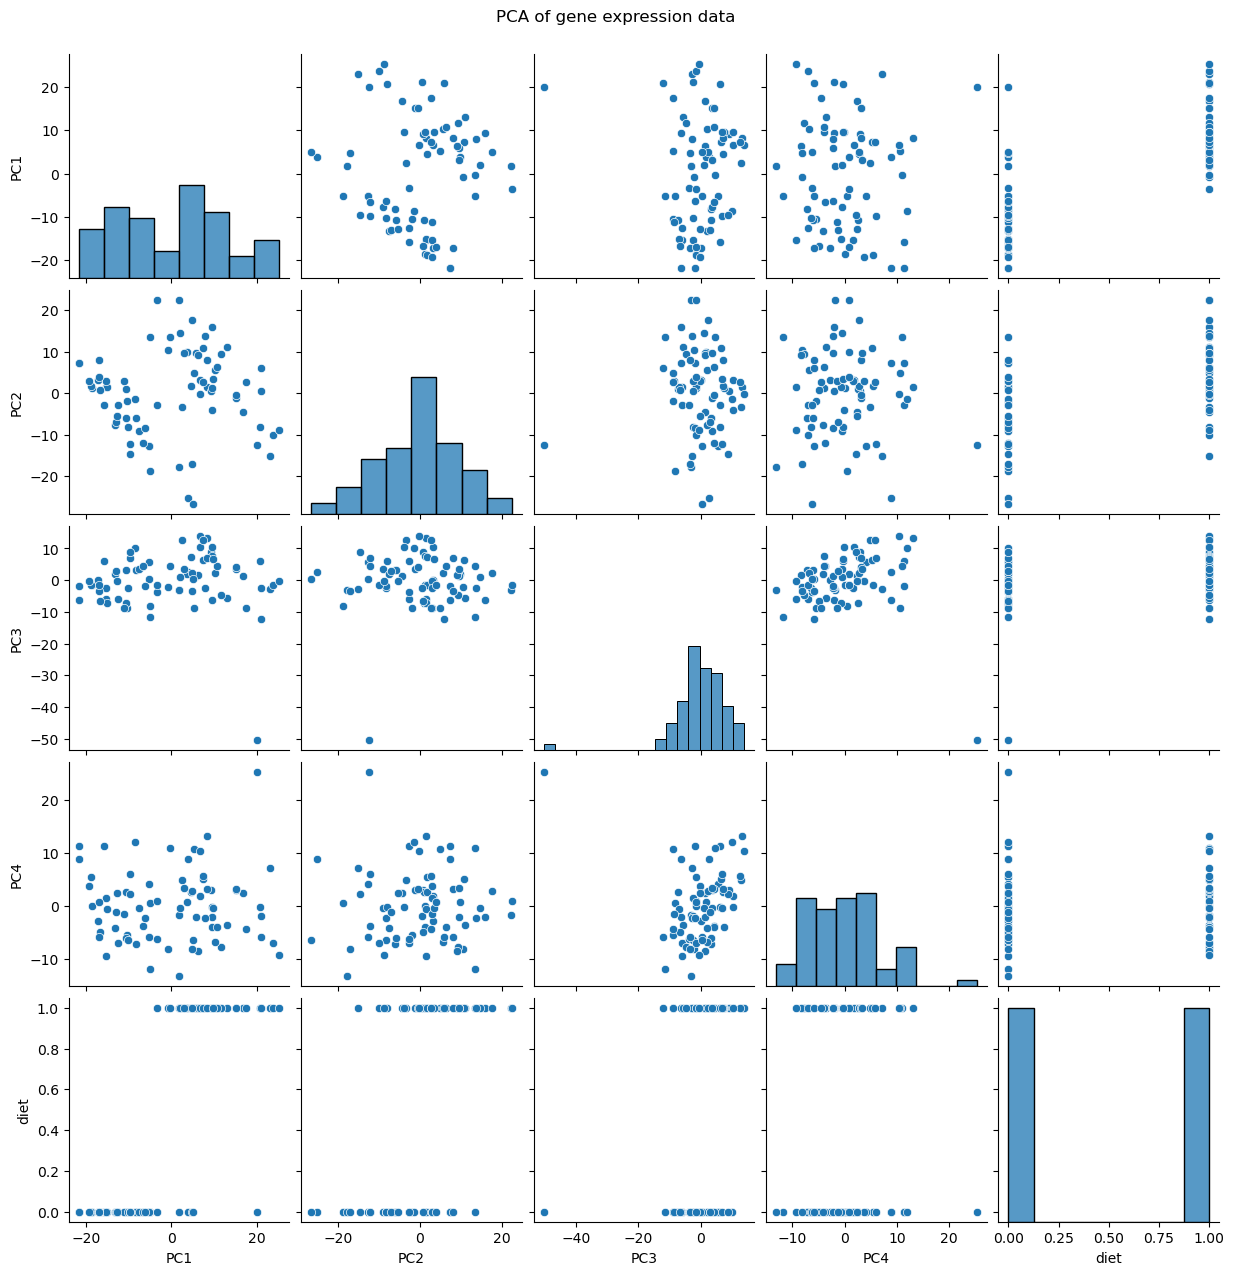

In [55]:
# YOUR CODE HERE
sns.pairplot(pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])]).assign(diet=is_hfd.values))
plt.suptitle('PCA of gene expression data', y=1.02)
plt.show()

## Add color information based on the diet
`sns.pairplot` can color points based on the values of a column specified by `hue` keyword, so add `is_hfd` we had prepared earlier as a new column to `pc_df`. **PCA of course did not use the color labels, you only added them afterwards. In light of this, do you find the plots impressive?**

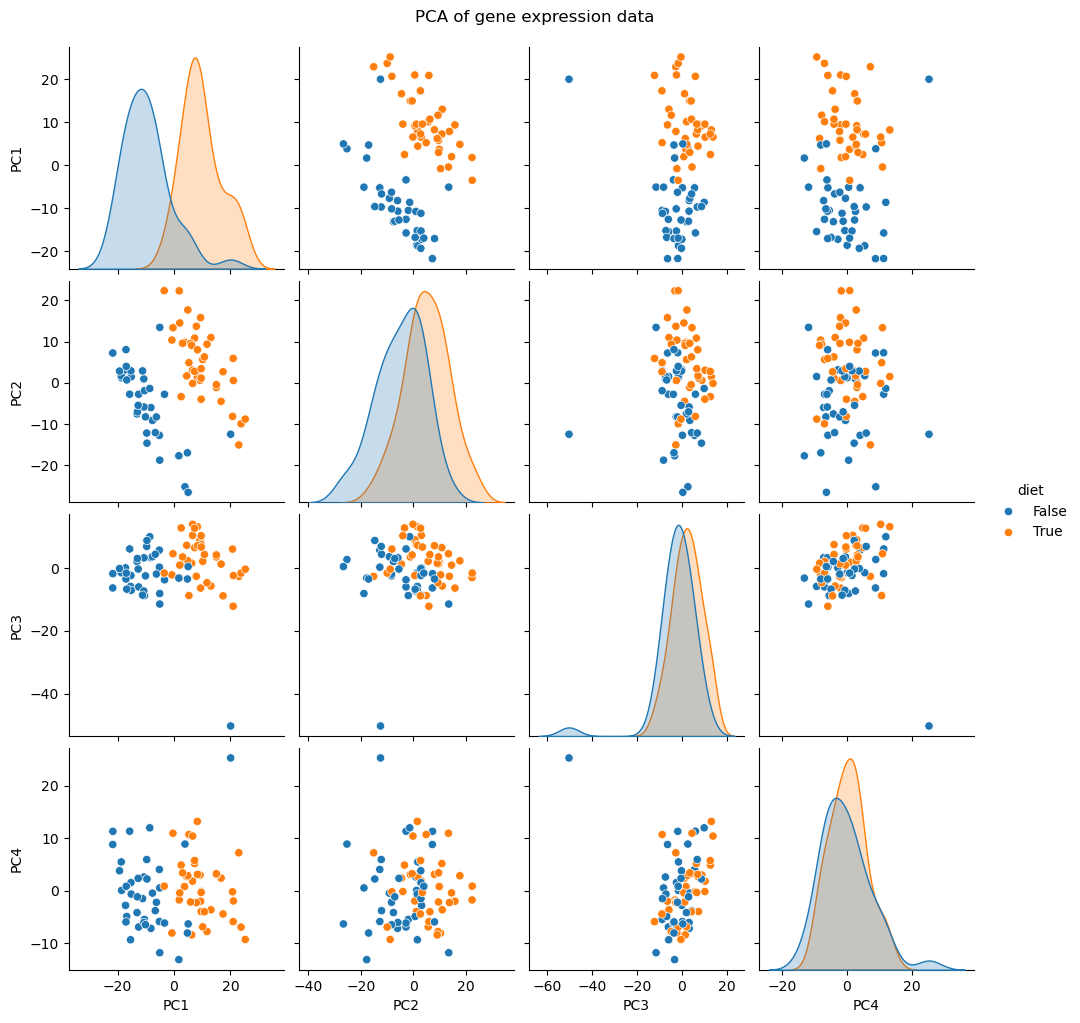

In [56]:
# YOUR CODE HERE
sns.pairplot(pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])]).assign(diet=is_hfd.values), hue='diet')
plt.suptitle('PCA of gene expression data', y=1.02)
plt.show()

Generally, a combination of the first two components already leads to a fairly good separation of the expression profiles with a differing diet. Interestingly, this can also be seen as the fitted distributions for the projections, where the captured variance should be highest in the first two components, and here the fitted distributions of the components showcase the biggest separation of the data. 

## Optional: repeat the above steps using every 200th gene only. Is the PCA plot still informative?
If you choose to do this task, make sure not to overwrite the original results with all the data. You can keep every 200th gene by creating `data_small = data.iloc[:, ::200]`. We will return to using the full data after this optional subtask.

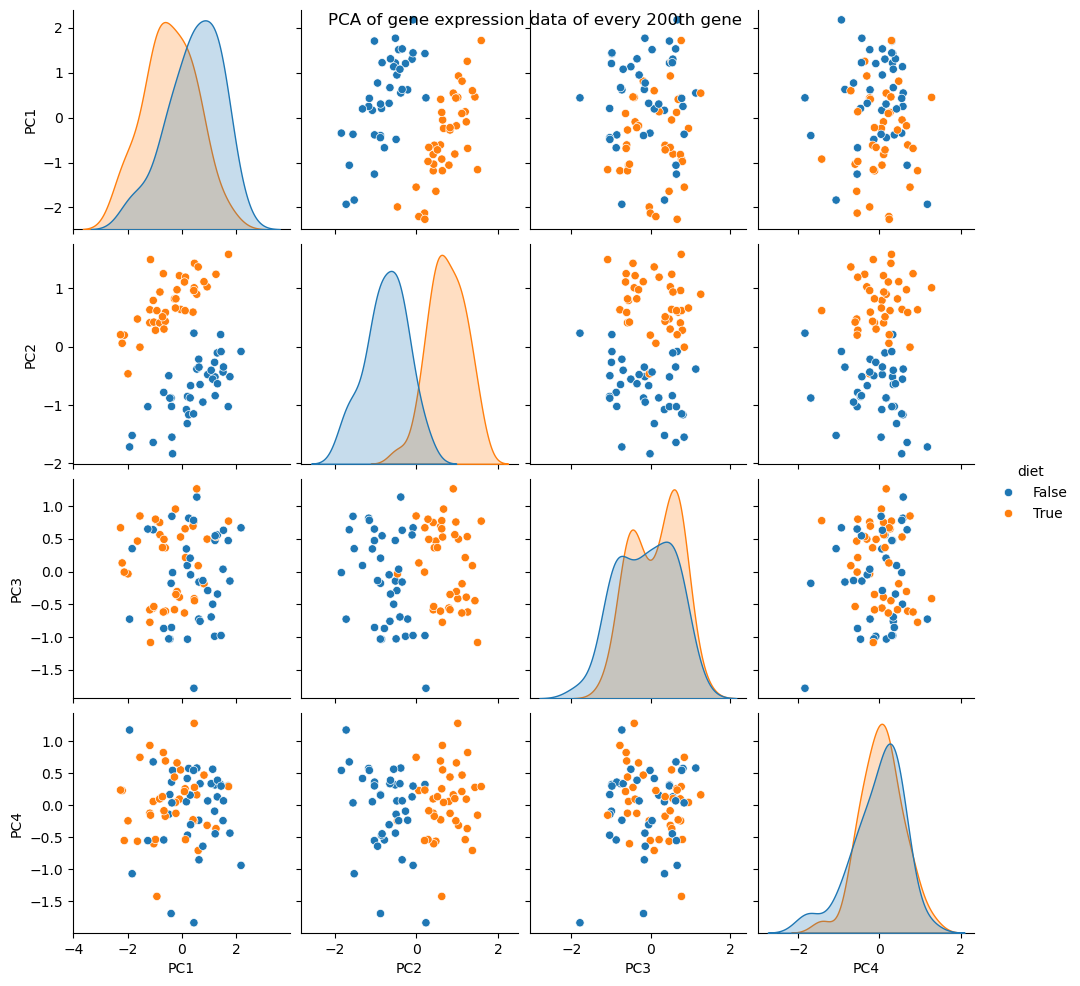

In [57]:
# YOUR CODE HERE
data_small = data.iloc[:, :200]  
pca_model_small = PCA(n_components=4)
pca_result_small = pca_model_small.fit_transform(data_small)
sns.pairplot(pd.DataFrame(pca_result_small, columns=[f'PC{i+1}' for i in range(pca_result_small.shape[1])]).assign(diet=is_hfd.values), hue='diet')
plt.suptitle('PCA of gene expression data of every 200th gene')
plt.show()

Interestinlgy, the separation becomes even more pronounced for all principle components, especially for the smaller principal components. This is probably due to reduced noice in less genes.

## Find the principal directions of the fitted PCA. Are they orthogonal and unit length as promised?
<div class="alert alert-block alert-warning">Confusingly, <code>scikit-learn</code> (and unfortunately a lot of people as well) like to call the principal directions as "principal components", overloading the term, since it is already used to refer to the transformed values as well (a brief discussion <a href="https://stats.stackexchange.com/questions/88118/what-exactly-is-called-principal-component-in-pca">here</a>)</div>

Anyway, you will find the principal direction vectors in `pca.components_`. You will see that it's a 21835x4 matrix, where 4 stands for the number of principal directions that you had computed, and 21835 stands for the number of features (genes) in your dataset. Check whether these 21835-dimensional direction vectors are indeed unit length, and whether all pairs of them are orthogonal to each other.

In [58]:
# YOUR CODE HERE
vectors = pca_model.components_
orthogonal = np.allclose(vectors @ vectors.T, np.eye(vectors.shape[0]), atol=1e-10)
print(orthogonal)
unit_length = np.allclose(np.linalg.norm(vectors, axis=1), 1)
print(unit_length)

True
True


They are orthogonal to each other and all have unit length.

## How correlated are the transformed values (principal components) with each other? Why is it important?

In [59]:
# YOUR CODE HERE
cor = pearsonr(vectors[0], vectors[1])
print(cor)

PearsonRResult(statistic=np.float64(0.005242802733764073), pvalue=np.float64(0.4385331027190077))


They are very uncorrelated, which makes sense since they are orthogonal vectors.

## Compare the first principal direction's weights with the log-fold-change vector from your differential expression analysis. Visualize them on a scatter plot, and interpret what you see.
Remember, you had computed the fold-change values by comparing expression values between CD and the HFD diets. PCA had no access to the diet information, and yet...

You can also try a scatter plot for weight vs p-values, log10-p, etc. Some of them might look familiar.

<div class="alert alert-block alert-info"><b>Tip: </b> turn the matrix containing the principal direction vectors into a DataFrame called <code>direction_df</code>, and add the gene indices. This will make your life easier.</div>

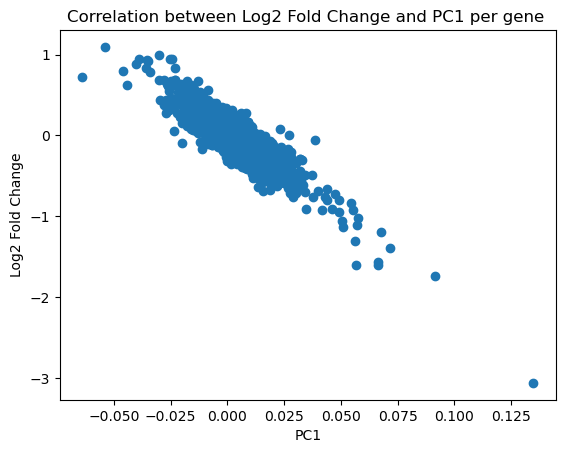

In [60]:
# YOUR CODE HERE
pc1 = vectors[0]
log_fold_changes = diffexpr.loc[data.columns]['log2fold']
plt.scatter(pc1, log_fold_changes)
plt.ylabel('Log2 Fold Change')
plt.xlabel('PC1')
plt.title('Correlation between Log2 Fold Change and PC1 per gene ')
plt.show()

One can see, that the projection of the gene on the first principal component has a strong negative correlation with the log-fold changes. This means, that the first principal component captures the expression strength of the genes between the two conditions is one of the main contributors to the variance in our data.

## Create a scatter plot for PC1 vs PC2 only, but this time connect pairs of points that come from the same strain

Every mouse strain was measured twice, and therefore they each contribute two points to the PCA plot. Connect these pairs of points: it will involve `plt.scatter`, and a `for` loop with `plt.plot` calls.

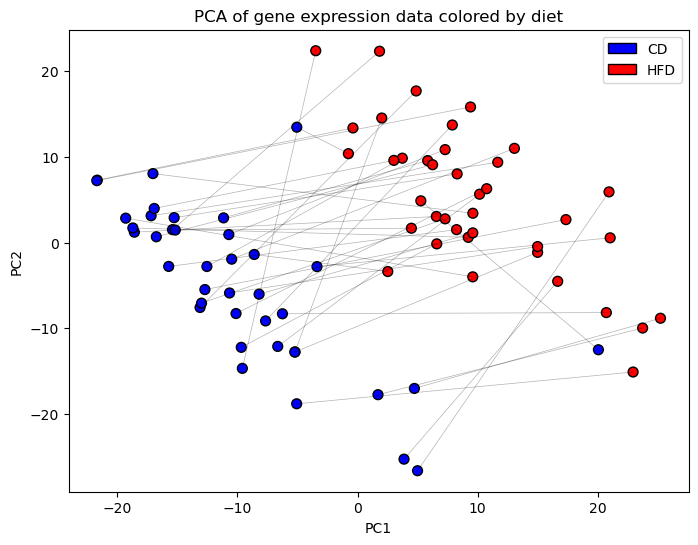

In [61]:
# YOUR CODE HERE
plt.figure(figsize=(8, 6))
colors = ['blue' if not hfd else 'red' for hfd in is_hfd.values]
plt.scatter(pca_result['PC1'], pca_result['PC2'], c=colors, edgecolor='k', s=50)
strains = pca_result.index.get_level_values('strain')
unique_strains = strains.unique()
for strain in unique_strains:
    strain_data = pca_result[strains == strain]
    if len(strain_data) == 2:  
        plt.plot(strain_data['PC1'], strain_data['PC2'], 'k-', alpha=0.3, linewidth=0.5)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of gene expression data colored by diet')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', edgecolor='k', label='CD'),
                   Patch(facecolor='red', edgecolor='k', label='HFD')]
plt.legend(handles=legend_elements, loc='best')
plt.show()

**What does the angle of the lines represent here? What do the horizontal lines say about our data?**

The angle corresponds to the impact of each principal component to the variance in the strain. So a low angle corresponds to a higher impact of PC1, while an angle closer to 90° corresponds to a higher impact of the second principal component.

# Hierarchical clustering

You had created cluster-maps before with dendrograms on the top and/or left edges of the figure. They are a result of an unsupervised technique called hierarchical clustering. It iteratively merges single data points into bigger and bigger clusters based on their similarity, one at a time, until all points belong to one big cluster. Seaborn's `clustermap` does it on both axes by default, and produces a heatmap of the values as well.

## Create a clustermap
From your first PCA direction vector, take the genes with the 15 largest positive, and 15 largest negative weights, and create a smaller expression matrix with these 30 genes only. Use seaborn's `clustermap` to display a heatmap and a hierarchical clustering of genes and mice.

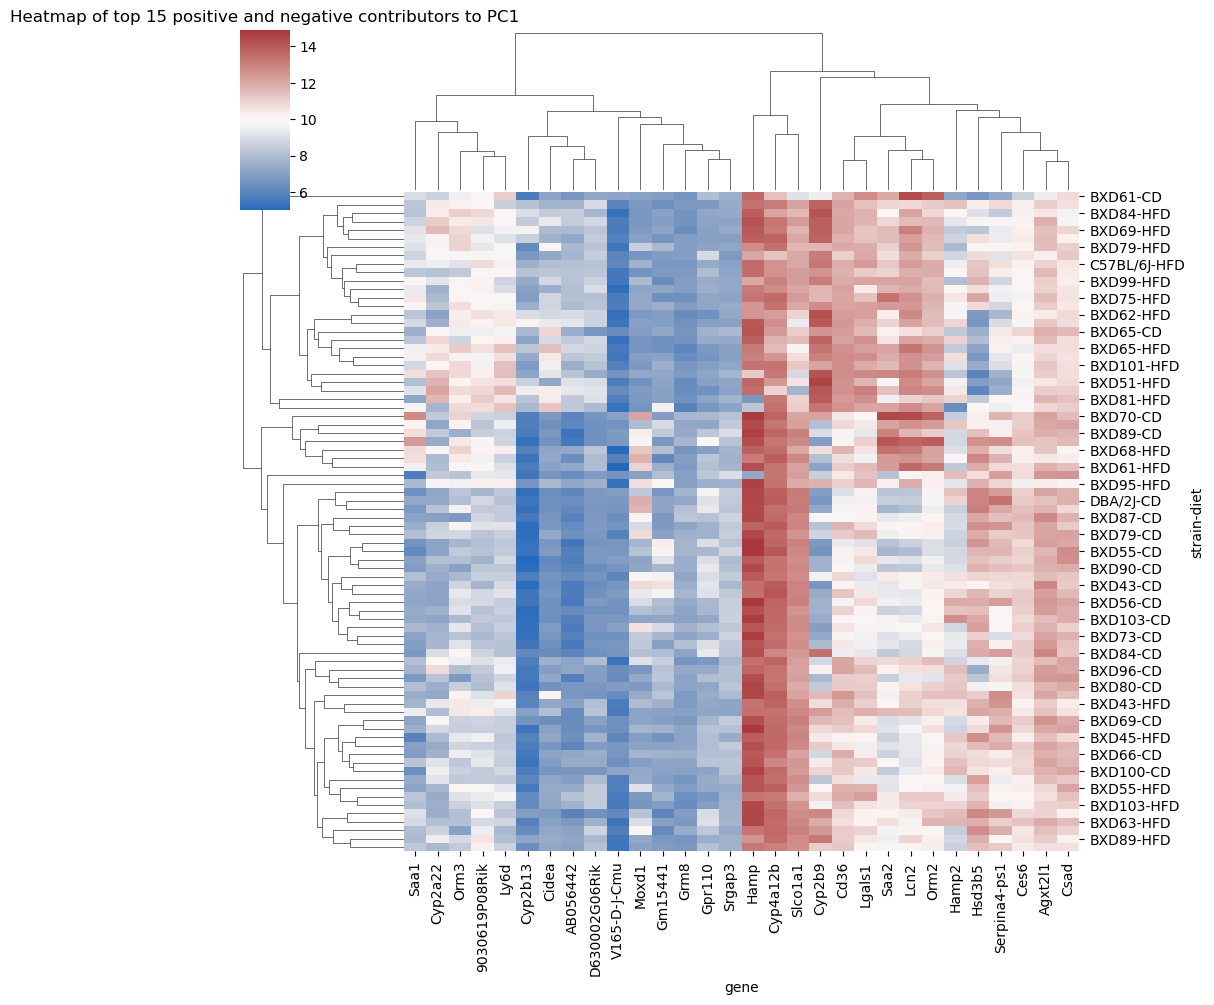

In [62]:
# YOUR CODE HERE
top15_pos = pd.Series(vectors[0], index=data.columns).nlargest(15)
top15_neg = pd.Series(vectors[0], index=data.columns).nsmallest(15)

sns.clustermap(data[top15_pos.index.union(top15_neg.index)], cmap='vlag', col_cluster=True)
plt.title('Heatmap of top 15 positive and negative contributors to PC1')
plt.show()

## Display the diet as color labels on the corresponding dendrogram
You will have to convert `is_hfd`'s boolean values to color values first: `y` or `yellow` for `True` and `b` or `blue` for `False` should do fine. Make use of the `.replace` method of Series, and use the dictionary encoding `{True: 'yellow', False: 'blue'}`.

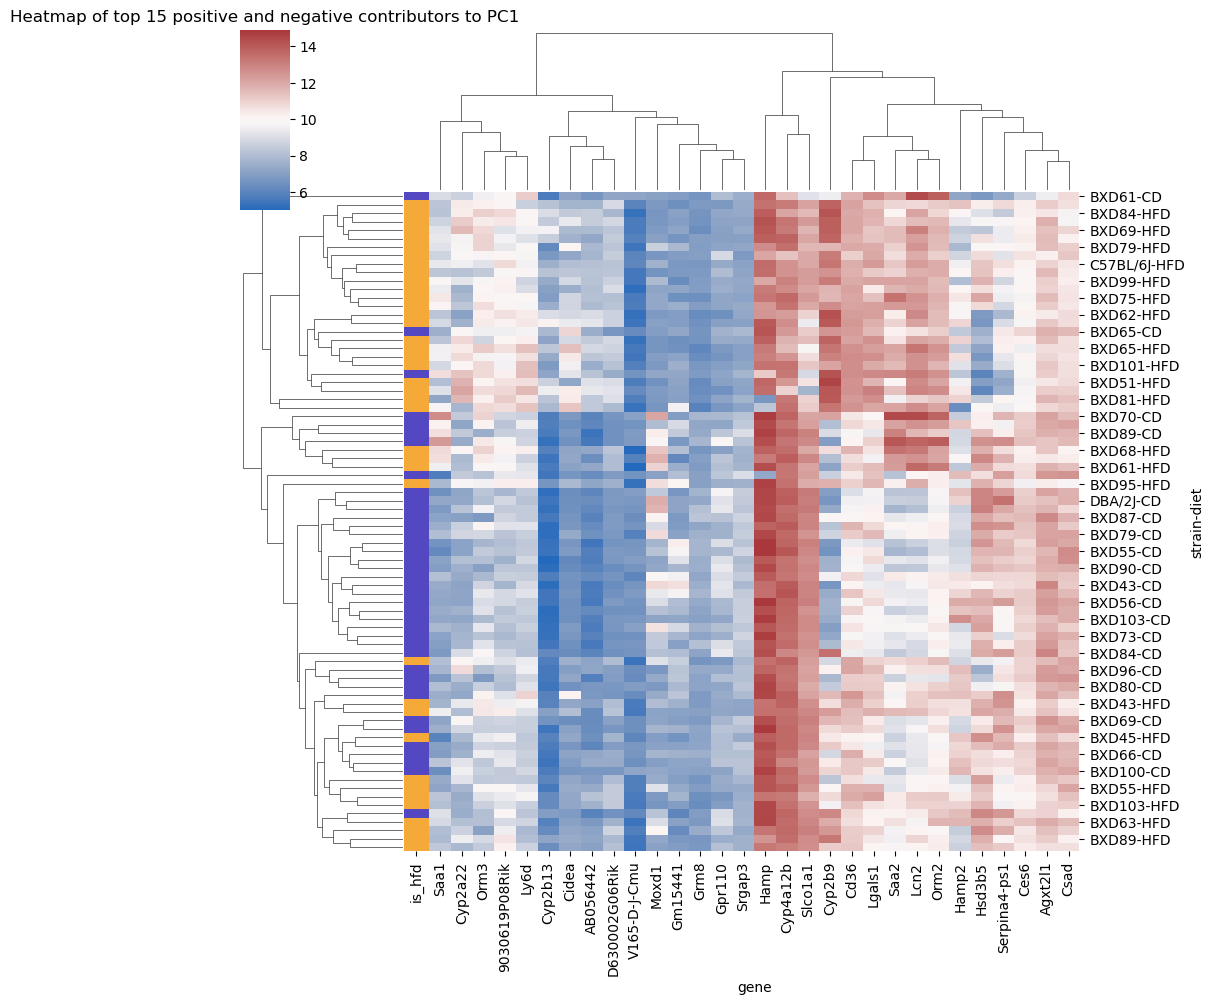

In [63]:
# YOUR CODE HERE
is_hfd.replace({True: '#f5a938', False: '#5448c2'}, inplace=True)
sns.clustermap(data[top15_pos.index.union(top15_neg.index)], cmap='vlag', col_cluster=True, row_colors=is_hfd)
plt.title('Heatmap of top 15 positive and negative contributors to PC1')
plt.show()


## Standardize the matrix and visualize the clustermap again
Like we saw yesterday, it is hard to see the fine differences between the gene expression levels across mice, because the range of general expression levels across genes is much higher. To circumvent this, we standardize our data: for every gene, subtract the mean and optionally divide by the standard deviation.

You can do this with yesterday's pandas one-liner, or as a clustermap keyword setting, or with sklearn's `StandardScaler` tool.

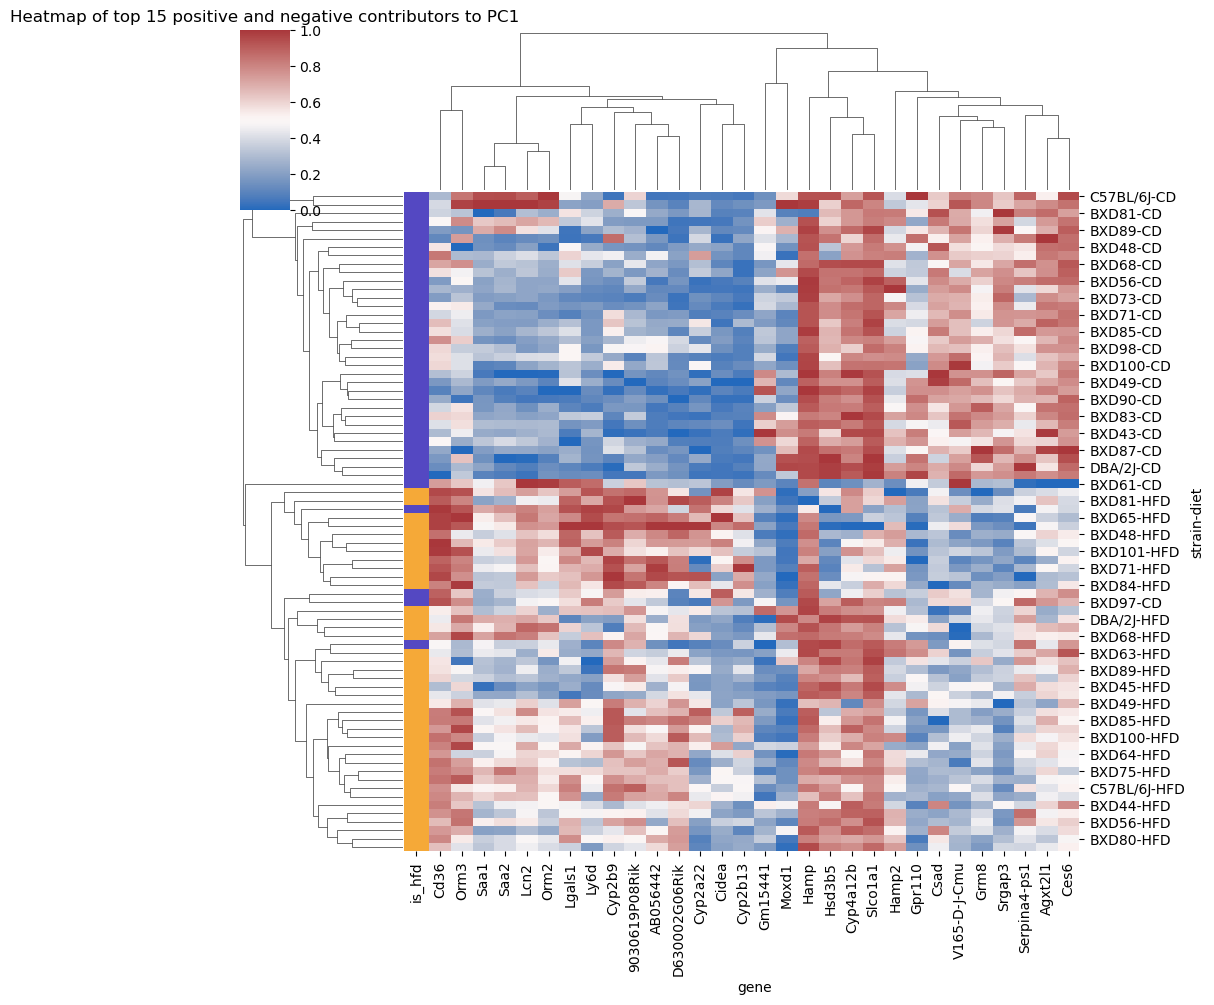

In [64]:
# YOUR CODE HERE
sns.clustermap(data[top15_pos.index.union(top15_neg.index)], cmap='vlag', col_cluster=True, row_colors=is_hfd, standard_scale=1)
plt.title('Heatmap of top 15 positive and negative contributors to PC1')
plt.show()

## Try different linkage methods
The linkage method changes the definition of cluster similarities. For example, `single` defines the distance of two clusters as the smallest distance of any two elements between them. Its opposite is `complete` which takes the largest distance of any two elements between the two clusters. Between these two extremes are `centroid`, `average`, and a few more. Look at how they affect the topology of the clusters. Which one seems most suitable in our case?

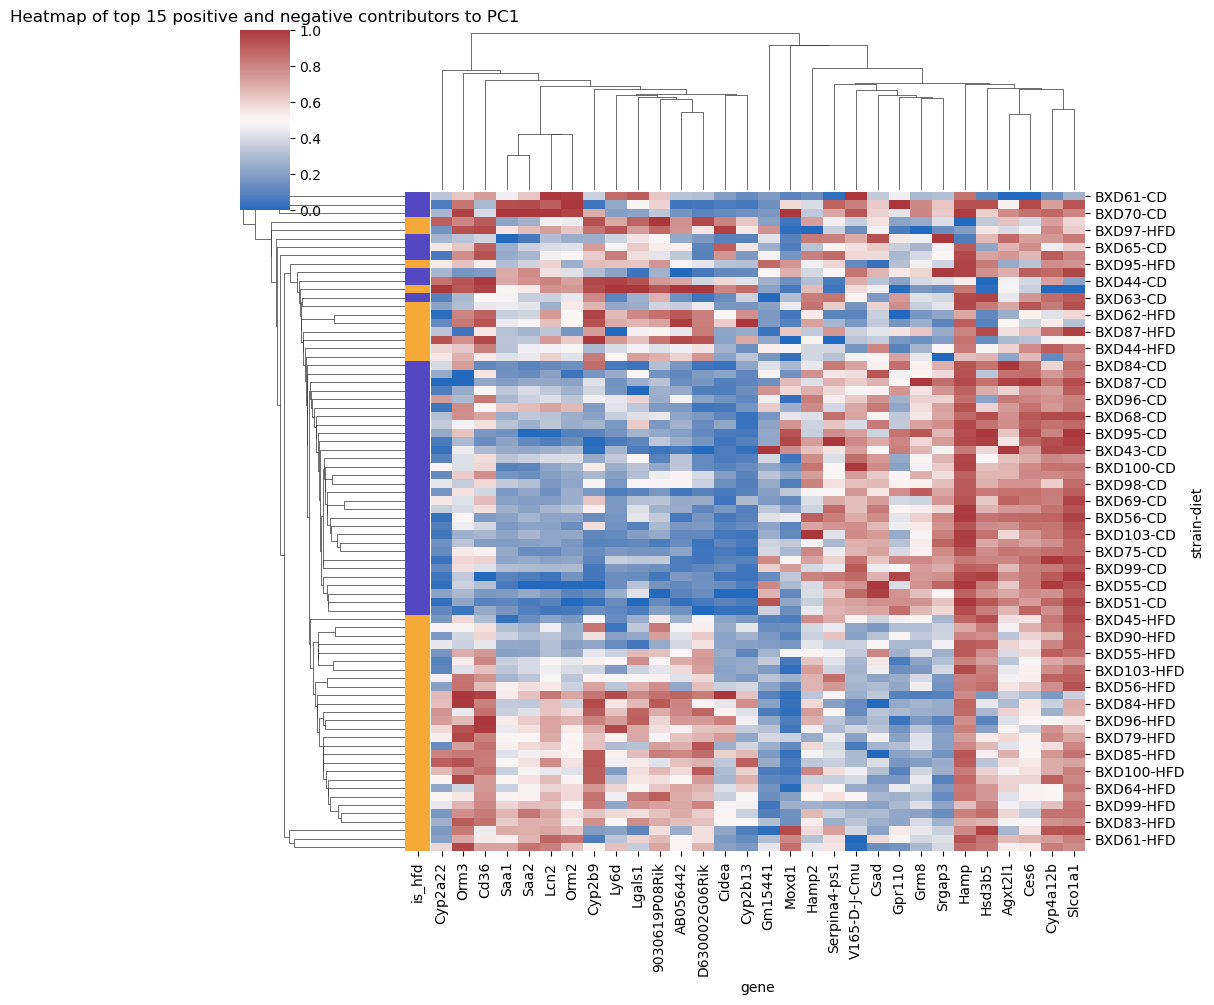

In [65]:
# YOUR CODE HERE
sns.clustermap(data[top15_pos.index.union(top15_neg.index)], cmap='vlag', col_cluster=True, row_colors=is_hfd, standard_scale=1, method='single')
plt.title('Heatmap of top 15 positive and negative contributors to PC1')
plt.show()

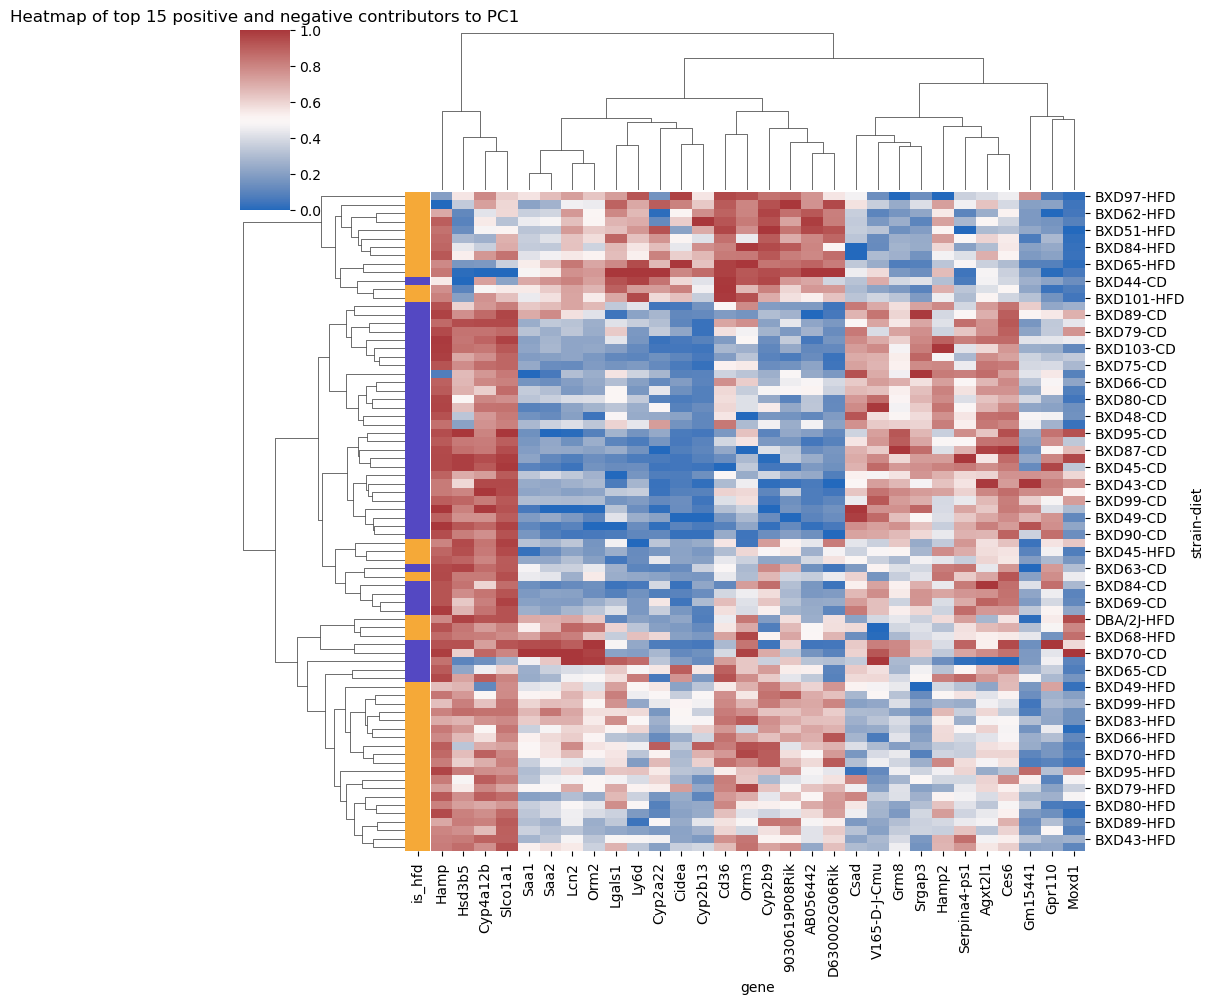

In [66]:
# YOUR CODE HERE
sns.clustermap(data[top15_pos.index.union(top15_neg.index)], cmap='vlag', col_cluster=True, row_colors=is_hfd, standard_scale=1, method='complete')
plt.title('Heatmap of top 15 positive and negative contributors to PC1')
plt.show()

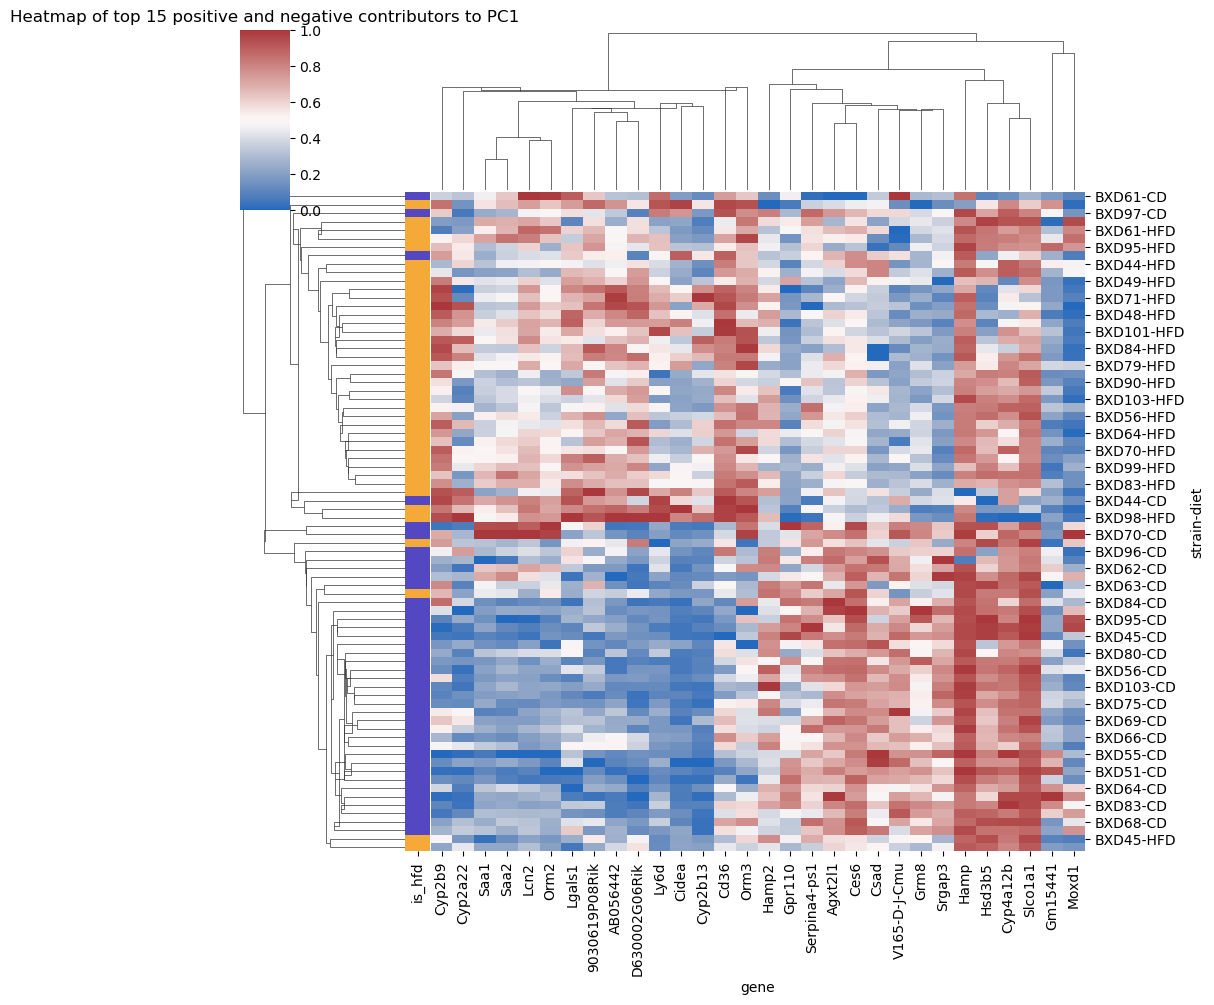

In [67]:
sns.clustermap(data[top15_pos.index.union(top15_neg.index)], cmap='vlag', col_cluster=True, row_colors=is_hfd, standard_scale=1, method='centroid')
plt.title('Heatmap of top 15 positive and negative contributors to PC1')
plt.show()

# K-means clustering

K-means clustering attempts to create `k` virtual samples, whose average distances to the nearest actual samples is as small as possible. These `k` virtual samples are called cluster centers/prototypes or centroids. Each sample is assigned to the nearest centroid, therefore partitioning the samples to k clusters.

## Perform k-means clustering on the expression dataset. What k would be the natural choice?

In [68]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit(data)
data['cluster'] = clusters.labels_
centroids = kmeans.cluster_centers_
centroids_pca = pca_model.transform(centroids)

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


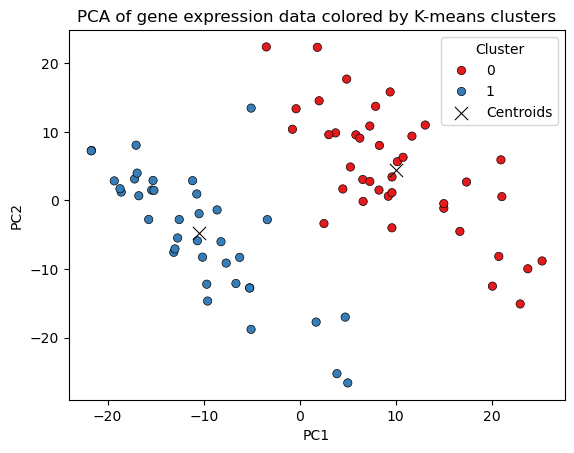

In [69]:
# YOUR CODE HERE
# Transform the centroids using the fitted PCA model
sns.scatterplot(x=pca_result['PC1'], y=pca_result['PC2'], hue=data['cluster'], palette='Set1', edgecolor='k')
sns.scatterplot(x=centroids_pca[:, 0], y=centroids_pca[:, 1], c='black', marker='x', s=90, label='Centroids')
plt.title('PCA of gene expression data colored by K-means clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster') 
plt.show()

The natural choice for k is 2, since we would expect two well separated clusters for each diet, assuming that the genotype does have a lower impact.

## Compare the resulting clusters with the diet labels
<div class="alert alert-block alert-info"><b>Tip: </b> remember <code>crosstab</code>? You can concatenate the cluster labels with the diet information and cross-tabulate them, interpret the results.</div>

Optional: try higher k-values, and investigate the resulting clusters.

In [70]:
# YOUR CODE HERE
crosstab = pd.crosstab(data['cluster'], is_hfd2)
print(crosstab)

is_hfd   False  True 
cluster              
0            1     39
1           38      0


One can clearly see, that the cluster assignments almost perfectly match the diet background. So the data can be separated really well by k-means clustering.

##  With k=2, take the centroids, and transform them with the same `pca_model` that you had trained earlier. Highlight them on the PC1 vs PC2 plot.

The cluster centers are virutal samples, which means they pretty much look like real data measured on real mice: they are a bunch of expression values. Of course they aren't real measurements, more like "representatives" of the K clusters. You can treat them as if they were proper samples, and therefore you can transform them re-using the PCA model from Task 2. This time you should use `.transform` instead of `.fit_transform` because you don't want to change the original model, only apply it to this new data.

**Before doing this, think about where you would expect them to fall. Did they?**

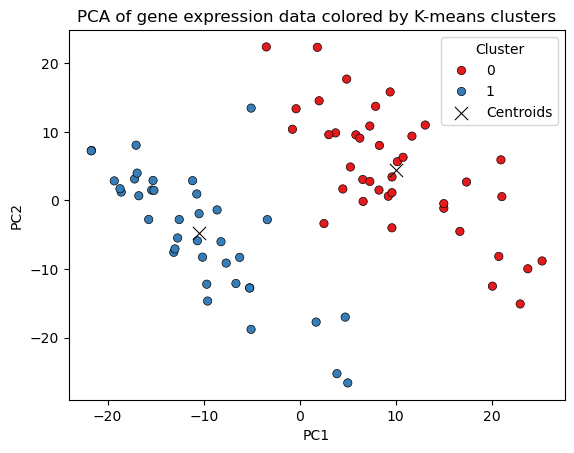

In [71]:
#s. above
sns.scatterplot(x=pca_result['PC1'], y=pca_result['PC2'], hue=data['cluster'], palette='Set1', edgecolor='k')
sns.scatterplot(x=centroids_pca[:, 0], y=centroids_pca[:, 1], c='black', marker='x', s=90, label='Centroids')
plt.title('PCA of gene expression data colored by K-means clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster') 
plt.show()

One clearly sees, that the projections of the cluster centroids lie in the respective diet groups fairly centered.

## Train a 2-means clustering model on half of the samples and predict cluster membership on the other half of the samples
Since the CD and HFD samples are alternating rows of our, you can just use `data.iloc[:len(data)//2]` for the training and `data.iloc[len(data)//2:]` for the prediction to split them evenly. **What do you find?**

In [ ]:
# YOUR CODE HERE
train = data.iloc[:len(data)//2]
test = data.iloc[len(data)//2:]
kmeans_train = KMeans(n_clusters=2, random_state=42)
clusters_train = kmeans_train.fit(train.drop(columns=['cluster']))
train['cluster'] = clusters_train.labels_
centroids_train = kmeans_train.cluster_centers_
centroids_train_pca = pca_model.transform(centroids_train)
confusion_matrix = pd.crosstab(test['cluster'], is_hfd2[len(train):])
print(confusion_matrix)

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


is_hfd   False  True 
cluster              
0            0     20
1           19      0


The prediction of the test data was perfect based on the k-means clustering on our training data. This can probably be explained by the high similarity of the datapoints within the groups, so that each point can be well described by similar points. 